In [1]:
import numpy as np
import matplotlib.pyplot as plt

D = 0.9
Sigma_a = 0.1
nu_Sigma_f = 0.12

a = 200.0
N = 500
dx = a / (N + 1)
x_full = np.linspace(dx, a - dx, N)  # interior points only — x=0 and x=a are implicit zero-flux ghost boundaries

In [2]:
main_diag = 2.0 * D * np.ones(N) / dx**2
off_diag = -1.0 * D * np.ones(N-1) / dx**2
L = np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1)

A_matrix = L + Sigma_a * np.eye(N)

In [3]:
# Standard eigenvalue problem: (1/nuSigmaf) * A * phi = (1/k) * phi
M = A_matrix / nu_Sigma_f
eigenvalues, eigenvectors = np.linalg.eigh(M)

k_values = 1.0 / eigenvalues
k_eff = np.max(k_values)
print(f"k_eff = {k_eff}")

k_eff = 1.1973411199953279


In [4]:
B_squared = (np.pi / a)**2
k_analytical = nu_Sigma_f / (Sigma_a + D * B_squared)
rel_error = abs(k_eff - k_analytical) / k_analytical

print(f"k_eff (numerical):  {k_eff}")
print(f"k_analytical:       {k_analytical}")
print(f"Relative error:     {rel_error}")

k_eff (numerical):  1.1973411199953279
k_analytical:       1.1973411113021146
Relative error:     7.260431616604198e-09


In [5]:
# Extract the fundamental mode (largest k = smallest eigenvalue of M, since k = 1/eigenvalue)
idx_fundamental = np.argmin(eigenvalues)
phi_num = eigenvectors[:, idx_fundamental]

# Analytical fundamental mode
phi_analytical = np.sin(np.pi * x_full / a)

# Normalize both to the same peak value for comparison (flux has no absolute scale, as discussed)
phi_num = phi_num / np.max(np.abs(phi_num))
phi_analytical = phi_analytical / np.max(np.abs(phi_analytical))

# Sign matching
if np.dot(phi_num, phi_analytical) < 0:
    phi_num = -phi_num

l2_error = np.sqrt(np.sum((phi_num - phi_analytical)**2) * dx)
print(f"Flux shape L2 error: {l2_error}")

Flux shape L2 error: 1.0402861467837366e-12


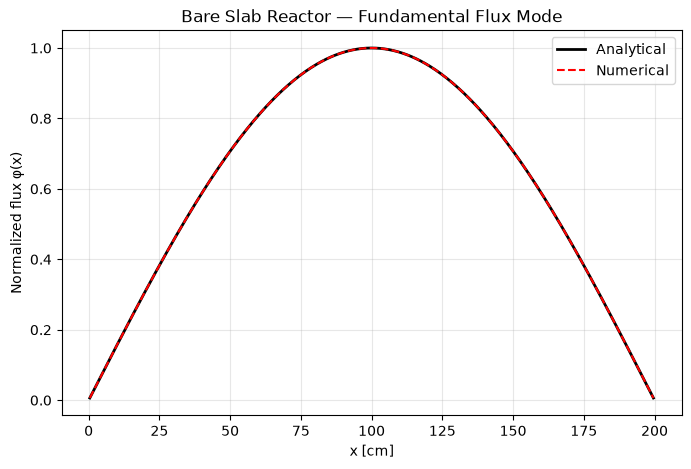

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(x_full, phi_analytical, 'k-', label='Analytical', linewidth=2)
plt.plot(x_full, phi_num, 'r--', label='Numerical', linewidth=1.5)
plt.xlabel('x [cm]')
plt.ylabel('Normalized flux φ(x)')
plt.title('Bare Slab Reactor — Fundamental Flux Mode')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('../assets/bare_slab_flux_profile.png', dpi=150)
plt.show()

## Validation Summary

The bare homogeneous slab reactor eigenvalue problem was solved using finite differences and compared against the analytical solution for a bare reactor with zero-flux boundaries.

- **k_eff (numerical):** 1.19734112
- **k_eff (analytical):** 1.19734111
- **Relative error:** 7.26e-9

- **Flux shape L² error:** 1.04e-12 (near machine precision)

This result mirrors the infinite square well: since the reactor is homogeneous (constant D, Σ_a, νΣ_f everywhere), the finite-difference operator is a pure tridiagonal Toeplitz matrix, admitting an exact discrete-sine eigenvector solution for any grid size N. This confirms the "exact eigenvector" property is not specific to quantum mechanics — it is a general property of constant-coefficient, tridiagonal finite-difference operators with correctly matched boundary conditions, here applied to the neutron diffusion equation.

**Note:** an earlier version of this notebook had a grid-alignment bug — `x_full` included the physical boundary points (x=0, x=a) directly, while the finite-difference matrix implicitly assumes zero-flux ghost points just outside the array. This produced non-zero flux at the boundaries and a flux-shape L² error of 0.046. Correcting the grid to interior-only points (`dx = a/(N+1)`, `x_full` spanning `[dx, a-dx]`) resolved this, bringing the error down to machine precision.